# **CDS Project: Part 3**

*Institute of Software Security (E22)*  
*Hamburg University of Technology*  

## Learning objectives
---

- Choose an ML model architecture for vulnerability prediction
- Preprocess the dataset you created in project part 2 to fit the model you selected
- Split the dataset for cross validation
- Create the model training pipeline, train the model using the train set and optimize the model using the test set
- Create loss graphs of the learning behaviour
- Generate predictions for the validation set
- Evaluate the results using appropriate metrics (add questions: reduce overfitting? optional 5-fold cross validation)


## Materials
---

- Lecture Slides 2, 3, 5 and 6, 9.
- PyTorch Documentation: [Datasets and Data Loaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)
-


## Project Description

In this project, you will create, train and evaluate your own machine learning model to predict vulnerabilities in source code. In addition, you will preprocess the data to prepare it to be used in the learning pipeline.
You will be using the dataset created in part 2 in this part.

## **Task 1**

- There are several ML model architectures that you can use for vulnerabilitiy prediction such as RNN, CNN, Multilabel Perceptron (MLP), Gated Recurrent Units (GRU) and so on. Choose a suitable ML model architecture for your project based on the strenghts and weaknesses of these algorithms.

- For the model architecture, you can choose from 2 paths:
  1. Preprocess the functions into vectors and continue the learning process similar to project 1.
  For instance, the code in the dataset needs to be converted into some type of vector representation that can be processed by a machine. After selecting a suitable model, preprocess the content in your dataset accordingly. Several models are available to preprocess code data such as:
    - Code2Vec: https://code2vec.org/
    - CodeBERT: https://github.com/microsoft/CodeBERT/tree/master/UniXcoder
    - CodeT5: https://github.com/salesforce/CodeT5

  2. Choose a model architecture that is capable of handeling raw text inputs (LSTM, GRU, etc.) as an input layer. Further information on text processing using pytorch:
    - https://pytorch.org/text/stable/index.html
    - https://pytorch.org/tutorials/


In [ ]:
# Import required libraries

import json, os, glob, numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, classification_report, accuracy_score)

# Use a GPU when available; otherwise, fall back to the CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 82.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Device: cuda


## Task 2

- Split your dataset appropriately into train, test, and validation set and justify your split.  

In [ ]:
# Load the vulnerability dataset generated in Project Part 2.

PATH = "vuln_dataset.jsonl"
data = [json.loads(l) for l in open(PATH, encoding="utf-8") if l.strip()]

# Separate the raw function source code from the target labels.
X = [d["function"] for d in data]
y = np.array([int(bool(d["vulnerable"])) for d in data])

# Inspect the class distribution before preprocessing and splitting.
print("Total:", len(X), "| Vuln:", int(y.sum()), "| Safe:", int((y==0).sum()))

Total: 18108 | Vuln: 1780 | Safe: 16328


In [ ]:
# Convert each source-code function into a fixed-size CodeBERT embedding.
# Embeddings are generated in chunks so that long runs can be resumed without recomputing chunks that have already been saved to disk.

from transformers import AutoTokenizer, AutoModel
import time, math

B, MAX_LEN = 32, 256
CHUNK = 2048               
N = len(X)

# Load the pretrained CodeBERT tokenizer and encoder.
tok  = AutoTokenizer.from_pretrained("microsoft/codebert-base")
bert = AutoModel.from_pretrained("microsoft/codebert-base").to(DEVICE).eval()

for start in range(0, N, CHUNK):
    fname = f"emb_chunk_{start}.npy"
    if os.path.exists(fname):
        print("skip:", fname); continue
    stop = min(start + CHUNK, N)
    t0, vecs = time.time(), []

    # Disable gradient tracking as CodeBERT is used only as feature extractor.
    with torch.no_grad():
        for i in range(start, stop, B):
            j = min(i + B, stop)          
            batch = tok(X[i:j], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE=="cuda")):
                out = bert(**batch).last_hidden_state[:, 0, :]
            vecs.append(out.float().cpu().numpy())
    np.save(fname, np.concatenate(vecs).astype(np.float32))
    print(f"saved {fname}: {np.concatenate(vecs).shape[0]} rows ({time.time()-t0:.0f}s)")

print("done")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

saved emb_chunk_0.npy: 2048 rows (9s)
saved emb_chunk_2048.npy: 2048 rows (9s)
saved emb_chunk_4096.npy: 2048 rows (9s)
saved emb_chunk_6144.npy: 2048 rows (9s)
saved emb_chunk_8192.npy: 2048 rows (9s)
saved emb_chunk_10240.npy: 2048 rows (9s)
saved emb_chunk_12288.npy: 2048 rows (9s)
saved emb_chunk_14336.npy: 2048 rows (9s)
saved emb_chunk_16384.npy: 1724 rows (8s)
done


In [ ]:
# Load all saved embedding chunks in their original numerical order.
files = sorted(glob.glob("emb_chunk_*.npy"),
               key=lambda p: int(p.split("_")[2].split(".")[0]))

# Combine the chunks into one matrix with shape: (number of functions, CodeBERT embedding dimension).
E = np.concatenate([np.load(f) for f in files]).astype(np.float32)
assert E.shape[0] == len(X), f"MISMATCH {E.shape[0]} vs {len(X)}"
E = torch.tensor(E)
print("Ready:", tuple(E.shape))

Ready: (18108, 768)


In [ ]:
# Split the dataset into 70%/15%/15% train, test and validation set

idx = np.arange(len(X))
tr, tmp = train_test_split(idx, test_size=0.30, stratify=y, random_state=42)
te, va  = train_test_split(tmp, test_size=0.50, stratify=y[tmp], random_state=42)
for nm, ix in [("train",tr),("test",te),("val",va)]:
    print(f"{nm:5s} n={len(ix):6d}  vuln%={100*y[ix].mean():.1f}")

train n= 12675  vuln%=9.8
test  n=  2716  vuln%=9.8
val   n=  2717  vuln%=9.8


## Task 3
- Create a preprocessing and training/test pipeline. This can also be done in separate steps.
- Train the model on a small dataset (e.g.: 1000 samples depending on the computational capacity) and make sure everything is working properly
- Show a graph showing the changes in loss function druring the training epochs
- Select proper metrics to evaluate the performance of the model
- If everything works well, then change the model parameters (e.g: number of neurons, layer depth) and regenerate the results. Comapare these results with your previous results and elaborate your findings.

In [ ]:
# Define a configurable multilayer perceptron that classifies the 768-dimensional CodeBERT embeddings as safe or vulnerable.

class MLP(nn.Module):
    def __init__(self, hidden=(256,), drop=0.3):
        super().__init__()
        layers, d = [], 768
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(drop)]; d = h
        layers += [nn.Linear(d, 2)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def train_model(hidden, drop, idx_tr, idx_ev, epochs=40, lr=1e-3, bs=256):
    """Train an MLP and evaluate it on a supplied holdout subset."""
    torch.manual_seed(42)

    model = MLP(hidden, drop).to(DEVICE)

    # Weight the minority vulnerable class more strongly to reduce the effect of the dataset's class imbalance during optimization.
    ytr = y[idx_tr]
    w = torch.tensor([1.0, (ytr==0).sum()/max(1,(ytr==1).sum())],
                     dtype=torch.float32, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr, Ytr = E[idx_tr].to(DEVICE), torch.tensor(y[idx_tr]).to(DEVICE)
    Xev, Yev = E[idx_ev].to(DEVICE), torch.tensor(y[idx_ev]).to(DEVICE)
    trl, evl = [], []
    for ep in range(epochs):
        model.train()

        # Shuffle the training rows at the beginning of every epoch.
        perm = torch.randperm(len(idx_tr))
        tot = 0.0
        for i in range(0, len(idx_tr), bs):
            b = perm[i:i+bs]
            opt.zero_grad()
            l = loss_fn(model(Xtr[b]), Ytr[b])
            l.backward(); opt.step()

            # Accumulate a sample-weighted loss for the epoch average.
            tot += l.item() * len(b)
            
        model.eval()
        with torch.no_grad():
            trl.append(tot/len(idx_tr))
            evl.append(loss_fn(model(Xev), Yev).item())

    # Generate final class predictions for the evaluation subset.
    with torch.no_grad():
        pred = model(Xev).argmax(1).cpu().numpy()

    yt = y[idx_ev]
    p,r,f1,_ = precision_recall_fscore_support(yt, pred, average="binary", zero_division=0)
    return trl, evl, dict(accuracy=accuracy_score(yt,pred),precision=p,recall=r,f1=f1), (pred,yt)

print("model ready (mini-batch)")

model ready (mini-batch)


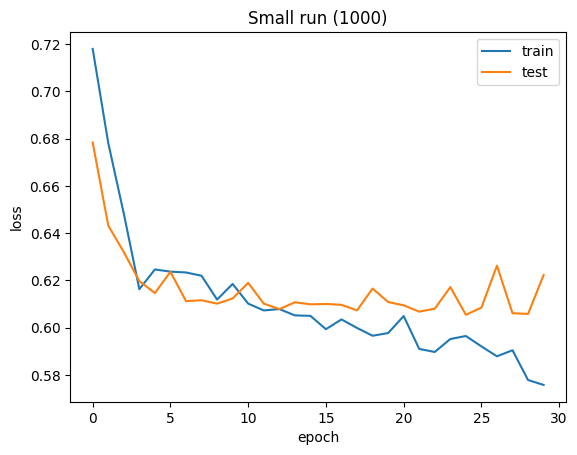

metrics: {'accuracy': 0.691, 'precision': 0.174, 'recall': 0.573, 'f1': 0.267}


In [ ]:
# smoke test on 1,000 training samples before the full experiment.

trl, evl, met, _ = train_model((128,), 0.3, tr[:1000], te, epochs=30)
plt.plot(trl, label="train"); plt.plot(evl, label="test")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Small run (1000)"); plt.legend(); plt.show()
print("metrics:", {k:round(v,3) for k,v in met.items()})


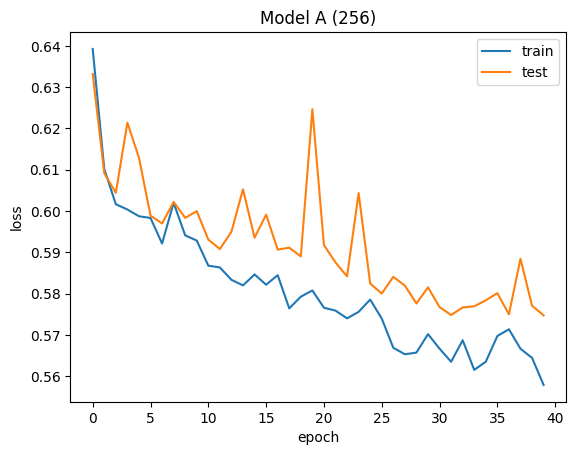

Model A: {'accuracy': 0.618, 'precision': 0.184, 'recall': 0.843, 'f1': 0.302}

Confusion [rows=true safe,vuln]:
 [[1453  996]
 [  42  225]]

               precision    recall  f1-score   support

        safe       0.97      0.59      0.74      2449
  vulnerable       0.18      0.84      0.30       267

    accuracy                           0.62      2716
   macro avg       0.58      0.72      0.52      2716
weighted avg       0.89      0.62      0.69      2716



In [ ]:
# Train Model A: one 256-neuron hidden layer with 30% dropout.

trA, evA, metA, (predA, ytA) = train_model((256,), 0.3, tr, te, epochs=40)

# Plot training and test loss to identify convergence or overfitting.
plt.plot(trA, label="train"); plt.plot(evA, label="test")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Model A (256)"); plt.legend(); plt.show()

print("Model A:", {k:round(v,3) for k,v in metA.items()})
print("\nConfusion [rows=true safe,vuln]:\n", confusion_matrix(ytA, predA))
print("\n", classification_report(ytA, predA, target_names=["safe","vulnerable"], zero_division=0))

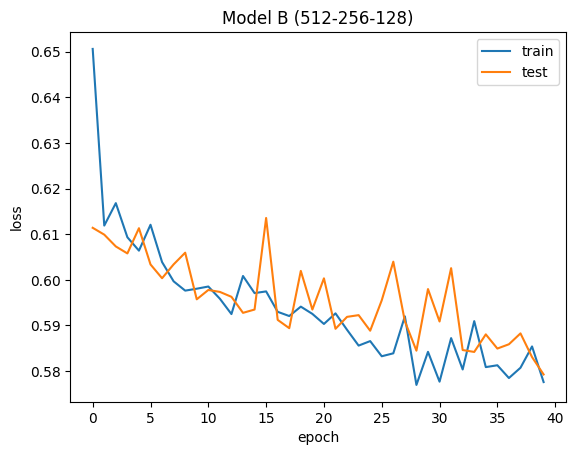

         accuracy  precision  recall     f1
Model A     0.618      0.184   0.843  0.302
Model B     0.566      0.170   0.876  0.284


In [ ]:
# Train Model B with a deeper architecture and stronger dropout.

trB, evB, metB, (predB, ytB) = train_model((512,256,128), 0.4, tr, te, epochs=40)
plt.plot(trB, label="train"); plt.plot(evB, label="test")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Model B (512-256-128)"); plt.legend(); plt.show()

# Present the two model configurations in one table for direct comparison.
print(pd.DataFrame({"Model A":metA, "Model B":metB}).T.round(3))

CDS Challenge

In [ ]:
def train_final(hidden, drop, idx_tr, epochs=40, lr=1e-3, bs=256):
    """Retrain the selected MLP configuration on all available labeled data."""
    torch.manual_seed(42)
    model = MLP(hidden, drop).to(DEVICE)
    ytr = y[idx_tr]

    # Preserve the same class-balancing strategy used during model selection.
    w = torch.tensor([1.0, (ytr==0).sum()/max(1,(ytr==1).sum())],
                     dtype=torch.float32, device=DEVICE)
    
    loss_fn = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    Xtr, Ytr = E[idx_tr].to(DEVICE), torch.tensor(y[idx_tr]).to(DEVICE)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(idx_tr))
        for i in range(0, len(idx_tr), bs):
            b = perm[i:i+bs]; opt.zero_grad()
            loss_fn(model(Xtr[b]), Ytr[b]).backward(); opt.step()
    model.eval(); return model

# Model A config = (256,),dropout 0.3 achieved the best F1 score in the comparison — retrained on all 18108 samples
final_model = train_final((256,), 0.3, np.arange(len(X)))
print("final Model A trained on", len(X), "samples")

final Model A trained on 18108 samples


In [ ]:
# Load the CDS challenge dataset

CH = "cds_challenge.jsonl"    
ch = [json.loads(l) for l in open(CH, encoding="utf-8") if l.strip()]

ch_ids  = [c["vul_id"] for c in ch]     
ch_code = [c["func"]   for c in ch]     
print("challenge samples:", len(ch_code))
print("first id:", ch_ids[0], "| code preview:", ch_code[0][:80])

challenge samples: 1000
first id: 29479 | code preview: private static native void nativeSetApkAssets(long ptr, @NonNull ApkAssets[] apk


In [ ]:
# Encode the challenge functions with the same tokenizer, truncation length, CodeBERT model, and [CLS] pooling strategy used for the training dataset.

vecs = []
with torch.no_grad():
    for i in range(0, len(ch_code), 32):
        b = tok(ch_code[i:i+32], padding=True, truncation=True,
                max_length=256, return_tensors="pt").to(DEVICE)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE=="cuda")):
            out = bert(**b).last_hidden_state[:, 0, :]
        vecs.append(out.float().cpu().numpy())

E_ch = torch.tensor(np.concatenate(vecs).astype(np.float32))
assert E_ch.shape[0] == len(ch_code), "count mismatch"
print("challenge embeddings:", tuple(E_ch.shape))

challenge embeddings: (1000, 768)


In [ ]:
# Predict the binary class for each challenge function.

with torch.no_grad():
    pred = final_model(E_ch.to(DEVICE)).argmax(1).cpu().numpy()

with open("predictions.jsonl", "w") as f:
    for vid, p in zip(ch_ids, pred):
        f.write(json.dumps({"vul_id": int(vid), "is_vul": int(p)}) + "\n")

print("wrote", len(pred), "rows | predicted vuln:", int(pred.sum()),
      f"({100*pred.mean():.1f}%)")
print(open("predictions.jsonl").readline())

wrote 1000 rows | predicted vuln: 493 (49.3%)
{"vul_id": 29479, "is_vul": 0}

